# Predicting Ad Clicks with Logistic Regression
I model ad-click likelihood based on demographic and behaviour information using a logistic regression model.

## About the Data

The advertising data contains information about online users and their interaction with ads, which was obtained from [Kaggle](https://www.kaggle.com/datasets/gabrielsantello/advertisement-click-on-ad). The data includes 9 input features and a categorical target variable (`Clicked on Ad`), with `1` representing a user clicking on an ad and `0` representing a user not clicking on an ad. Below is a summary of the features in the data:

* **Daily Time Spent on Site**: time individual spent on site in minutes
* **Age**: age of individual in years
* **Area Income**: average income of geographical area
* **Daily Internet Usage**: average time individual spent on the internet per day in minutes
* **Ad Topic Line**: headline of the ad
* **City**: city of the individual
* **Male**: whether or not the individual is male
* **Country**: country of the individual
* **Timestamp**: time at which the ad was clicked on or the window was closed
* **Clicked on Ad**: whether or not the ad was clicked on (target variable)

## Step 1. Load Packages and Data
We'll start by loading the Python packages that we'll need along with the data.

In [4]:
# math and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression

# misc 
import pycountry_convert as pc

# set seaborn style
sns.set_style('whitegrid')

# increasae pandas display width
pd.set_option("display.width", 180)

%matplotlib inline

In [5]:
# load data
df = pd.read_csv('./data/advertising.csv')

## Step 2. Exploratory Data Analysis

Next, we'll perform Exploratory Data Analysis (EDA) to obtain a deeper understanding of the data. EDA is essential for identifying patterns, outliers, correlations, and potential data quality issues. Our EDA will focus on the following:

- Review basic summary statistics to understand the central tendency and scale of numerical variables
- Check for missing values, invalid entries, or duplicate samples
- Search for high-cardinality categorical features
- Visualize feature distributions to help identify skewed distributions or outliers
- Inspect the target variable's distribution to identify any class imbalance
- Visualize feature distributions by the target variable

### Step 2.1. Basic Summary Statistics
We'll use `panda`'s `df.info()` function to see a high-level summary of each column and `df.describe()` function to review a summary of basic statistics of the numeric variables.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [9]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


There are a total of 1,000 data samples with 6 numeric columns and 4 object (categorical) columns. Among the numeric columns, there is a wide range in the central tendency and scale, which suggests that feature scaling might be required. The `Male` and `Clicked on Ad` column appears to be binary categorical variables stored as integers (0 or 1). The remaining object columns will likely need to be encoded to numerical form so they can be used by the model.

### Step 2.2. Check for Missing Values, Invalid Entries, or Duplicates
Next we look for missing values, invalid entries, and duplicate samples. I'll start by verifying that there are no `null` entries using `panda`'s `df.isnull()` function.

In [12]:
# look for null entries
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Ad Topic Line               0
City                        0
Male                        0
Country                     0
Timestamp                   0
Clicked on Ad               0
dtype: int64

While there are no `null` entries, I like to search the object columns for placeholders such as `?` and `...` that might represent missing data.

In [14]:
# define placeholder entries to search for
placeholders = ['?', '.', 'na', 'n/a', 'none']

for col in df.select_dtypes(include='object'):
    mask = df[col].isin(placeholders)
    if mask.any():
        print(f"{col}:\n {df[mask]}\n\n")
    else:
        print(f"{col}: No placeholder entries.")

Ad Topic Line: No placeholder entries.
City: No placeholder entries.
Country: No placeholder entries.
Timestamp: No placeholder entries.


Next, let's search for duplicate samples using `panda`'s `df.duplicated()` function.

In [16]:
# look for duplicate entries
df.duplicated().sum()

0

This reveals that there are no duplicated samples.

### Step 2.3. Search for High-Cardinality Categorical Features
Next, I'll search for categorical features with high cardinality.

In [19]:
print("Number of unique labels per categorical feature:\n")
for col in df.select_dtypes(include='object'):
    print(f"{col}: {df[col].nunique()}")

Number of unique labels per categorical feature:

Ad Topic Line: 1000
City: 969
Country: 237
Timestamp: 1000


These categorical features have very high cardinalities. In particular, `Ad Topic Line` and `Timestamp` are unique for each individual. Similarly, `City` is nearly unique for each individual. While `Country` has less unique labels than the other categorical features, there are still a significant number of categories. These high-cardinality categorical features will be addressed later on in the Feature Engeering section.

### Step 2.4. Visualize Feature Distributions
Now I will visualize the distribution of features, which is a simple yet effective way to identify data quality issues such as skewed distributions, missing data, and outliers. Since we know that some features have exceptionally high cardinality, plotting their distributions will be computationally intensive and unnecessary, so we won't include them here.

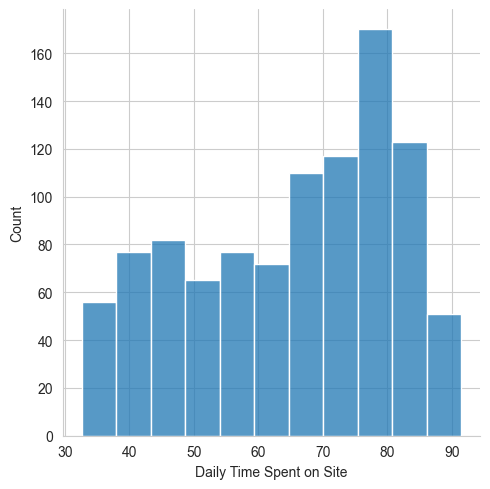

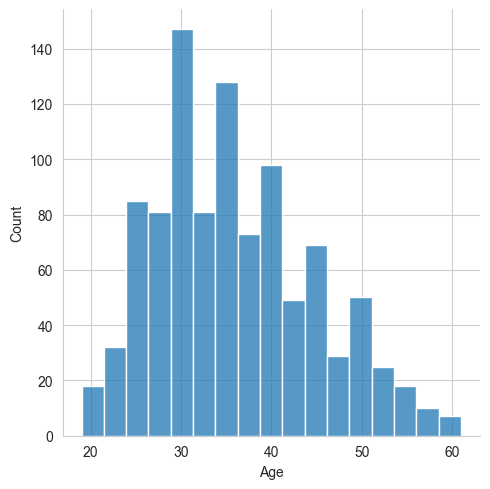

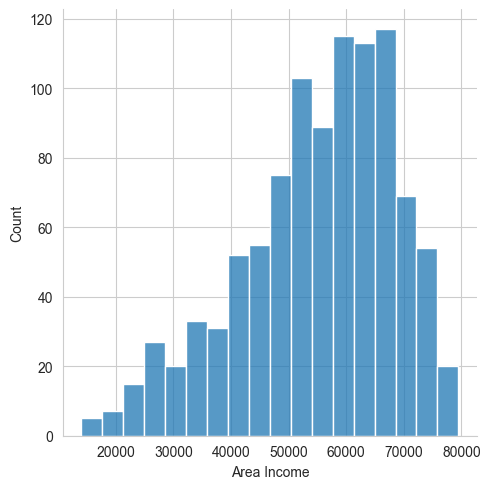

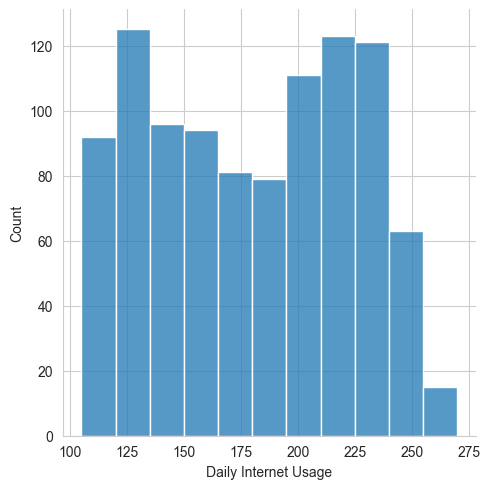

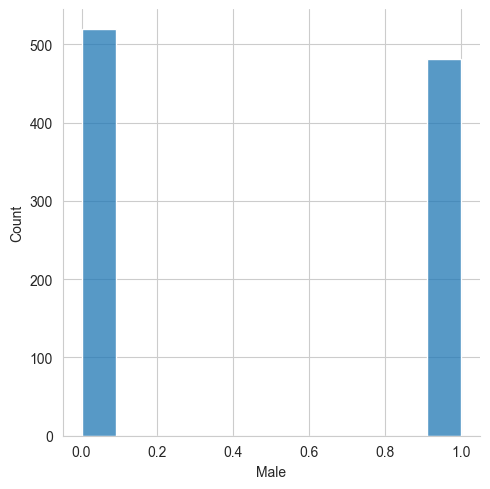

In [22]:
for col in df.drop(columns=['Clicked on Ad', 'Ad Topic Line', 'City', 'Country', 'Timestamp']).columns:
    sns.displot(data=df,x=col,kde=False)
    # rotate x-labels for continent plot
    if col=='Country':
        plt.xticks(rotation=45)

### Step 2.5. Visualize Target Variable Distribution
Let's now take a look at the distribution of the target variable, `Clicked on Ad`.

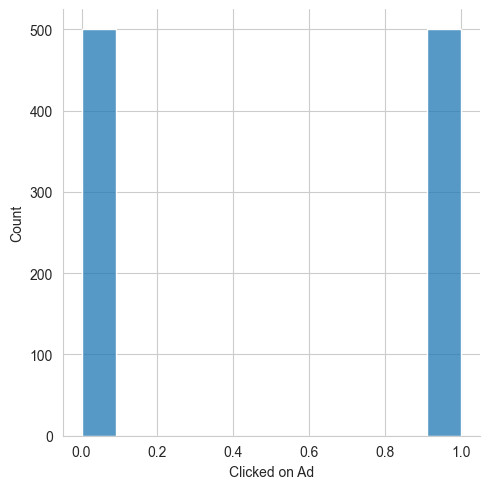

In [24]:
sns.displot(data=df,x='Clicked on Ad',kde=False)

The distribution of `Clicked on Ad` reveals that there is an equal number of individuals who clicked on an ad as those who didn't, so we don't need to worry about there being a class imbalance.

### Step 2.6. Visualize Feature Relationships
I will now visualize the relationships between numerical features using Seaborn's `sns.pairplot()` function, which shows scatterplots between different features on the off-diagonal elements and distributions of each feature along the diagonal elements. Using a colour scheme that differentiates between the two classes can be useful for identifying features that are linearly separable by class, which is an important underlying assumption of the logistic regression model. I will restrict this visual to the numerical features as they will be more straightfoward to interpret.

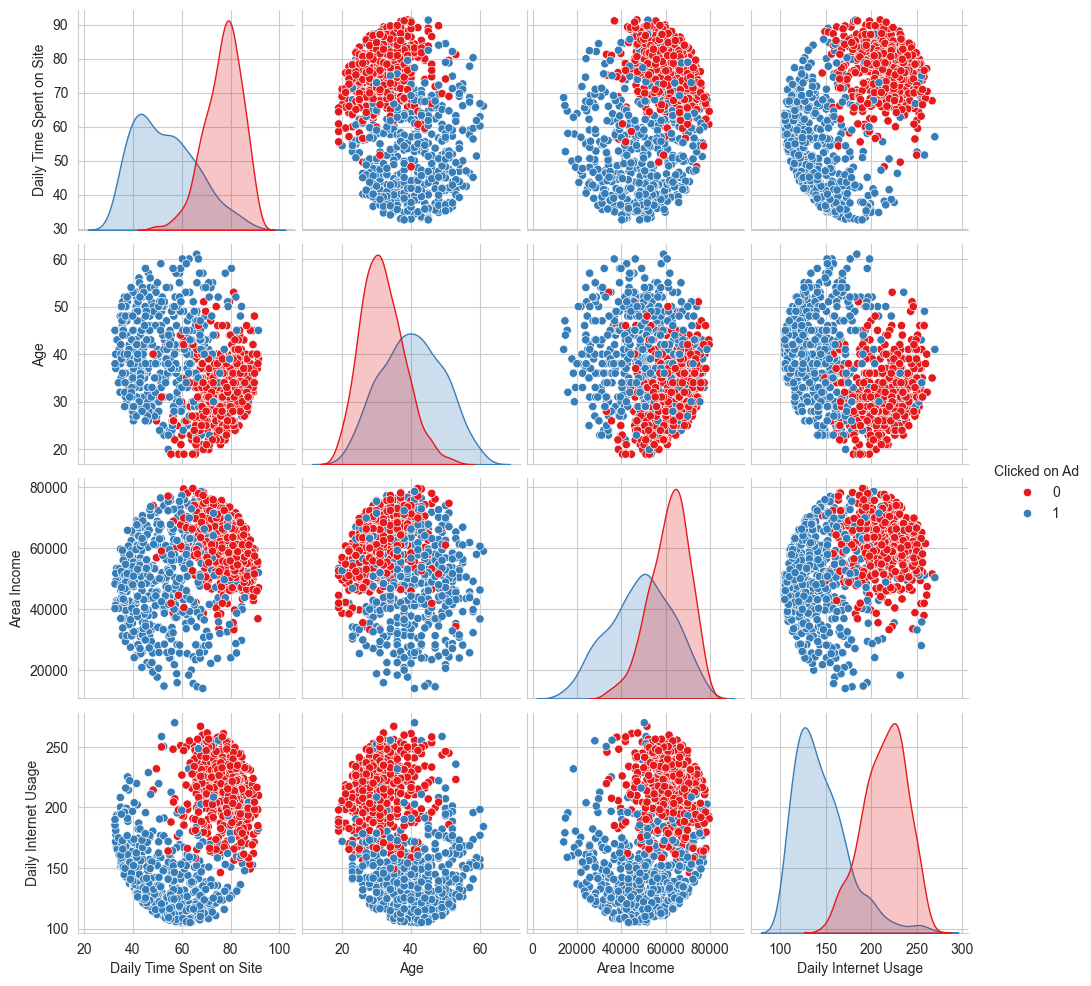

In [27]:
restricted_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Clicked on Ad']

# produce pairplot
sns.pairplot(data=df[restricted_features],hue='Clicked on Ad',palette='Set1')

The results of the pairplot demonstrate that this is a relatively simple dataset in the sense that all numerical features are relatively well separable by the class label. Since the logistic model is a linear classifier is feature space, the fact that the off-diagonal distributions are well separated by the target variable suggests that this dataset is well suited for a logistic regression model. 

## Step 3: Feature Engineering
My exploratory analysis revealed the following areas where feature engineering will be needed to prepare the data for the logistic regression model:

- high-cardinality features need to be transformed or reduced to prevent model over fitting
- categorical features need to be encoded to numerical form
- continuous features need to be scaled to a consistent distribution central tendency and width

### Step 3.1. Reduce High-Cardinality Features

I'll start by reducing high-cardinality features to prevent them from being one-hot encoded, which would cause the number of features to explode unnecessarily.

#### Step 3.1.1. `Ad Topic Line` and `City`

Recall that `Ad Topic Line` and `City` have unique entries for every data sample, which can be dropped since they don't add value to the model.

In [30]:
# drop Ad Topic Line, City
df = df.drop(columns=['Ad Topic Line', 'City'])

#### Step 3.1.2. `Country`

While `Country` doesn't have unique entries for every data sample, its cardinality is still quite high. To reduce its dimensionality, we'll use the `pycountry_convert` package to map each country to its corresponding continent. This involves obtain the country's tw-letter ISO code, which is used to obtain the continent code. Once we define a mapping between continent codes and continents, we can create a new `Continent` feature with significantly less unique labels than the original `Country` column.

In [32]:
def country_to_continent(country):
    '''
    Uses the pycountry_convert package to map countries to continents.
    '''

    # if country is known
    try:
        # use country to get country code
        country_code = pc.country_name_to_country_alpha2(country)
        # use country code to get continent code
        continent_code = pc.country_alpha2_to_continent_code(country_code)
        
        # define mapping between continent code and continent
        continent = {
            'AF': 'Africa',
            'NA': 'North America',
            'OC': 'Oceania',
            'AN': 'Antarctica',
            'AS': 'Asia',
            'EU': 'Europe',
            'SA': 'South America'
        }
        
        return continent.get(continent_code, 'Unknown')

    # if country is unknown
    except:
        return 'Unknown'

df['Continent'] = df['Country'].apply(country_to_continent)

Let's review the results of `Continent`. 

In [34]:
df['Continent'].value_counts()

Continent
Asia             211
Europe           203
Africa           192
North America    153
Oceania          100
Unknown           74
South America     64
Antarctica         3
Name: count, dtype: int64

It appears that 74 countries were mapped to `Unknown` continent, so let's review those.

In [36]:
df[df['Continent']=='Unknown']['Country'].unique()

array(['Palestinian Territory',
       'British Indian Ocean Territory (Chagos Archipelago)', 'Korea',
       'Bouvet Island (Bouvetoya)', 'Saint Helena',
       'Svalbard & Jan Mayen Islands', "Cote d'Ivoire", 'Timor-Leste',
       'Antarctica (the territory South of 60 deg S)', 'Western Sahara',
       'United States Minor Outlying Islands',
       'Holy See (Vatican City State)', 'French Southern Territories',
       'Pitcairn Islands', 'Libyan Arab Jamahiriya', 'Saint Barthelemy',
       'Reunion', 'Netherlands Antilles', 'Slovakia (Slovak Republic)'],
      dtype=object)

Since there aren't too many unique countries that were mapped to an `Unknown` continent, let's manually map these to their proper continents.

In [38]:
# define a manual mapping between remaining countries and their corresponding continents
manual_country_to_continent_mappings = {
    "Palestinian Territory": "Asia",
    "British Indian Ocean Territory (Chagos Archipelago)": "Asia",
    "Korea": "Asia",
    "Bouvet Island (Bouvetoya)": "Antarctica",
    "Saint Helena": "Africa",
    "Svalbard & Jan Mayen Islands": "Europe",
    "Cote d'Ivoire": "Africa",
    "Timor-Leste": "Asia",
    "Antarctica (the territory South of 60 deg S)": "Antarctica",
    "Western Sahara": "Africa",
    "United States Minor Outlying Islands": "Oceania",
    "Holy See (Vatican City State)": "Europe",
    "French Southern Territories": "Antarctica",
    "Pitcairn Islands": "Oceania",
    "Libyan Arab Jamahiriya": "Africa",
    "Saint Barthelemy": "North America",
    "Reunion": "Africa",
    "Netherlands Antilles": "North America",
    "Slovakia (Slovak Republic)": "Europe"
}

# apply manual mapping to countries where the continent is 'Unknown'
df.loc[df['Continent']=='Unknown', 'Continent'] = (df.loc[df['Continent']=='Unknown', 'Country']).map(manual_country_to_continent_mappings)

Let's review the results of `Continent` once more.

In [40]:
df['Continent'].value_counts()

Continent
Asia             225
Africa           214
Europe           214
North America    161
Oceania          106
South America     64
Antarctica        16
Name: count, dtype: int64

The 74 unknown continents have now been properly mapped, reducing the number of unique labels from 237 countries to 7 continents. With the new `Continent` feature complete, let's drop `Country`.

In [42]:
# drop Country column
df = df.drop(columns=['Country'])

#### Step 3.1.3. `Timestamp`

The `Timestamp` can be decomposed in a few different ways that can be meaningfully used by the model. For example, we could extract the hour of the day as an integer (i.e., 0 to 23 for each 24 hour of the day). However, representing time like this can create a misleading ordinal relationship in that the model would interpret hour 23 as being 'greater than' hour 0 even though they are adjacent in time. To preserve the cyclical nature of time, we can compute the sine (`hour_sin`) and cosine (`hour_cos`) components of the hour. This creates two continuous features that range from -1 to +1 that can be accurately interpreted by the model.

In [44]:
# convert timestamp to datetime object
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# extract integer hour
df['Hour'] = df['Timestamp'].dt.hour

# compute sine and cosine components of integer hour
df['Hour sine'] = np.sin(2.*np.pi*df['Hour']/24.)
df['Hour cosine'] = np.cos(2.*np.pi*df['Hour']/24.)

To ensure that we properly transformed `Hour` into its sine and cosine components and verify that these transformations are indeed cyclical in nature, let's review a plot of `Hour cosine` vs `Hour sine`.

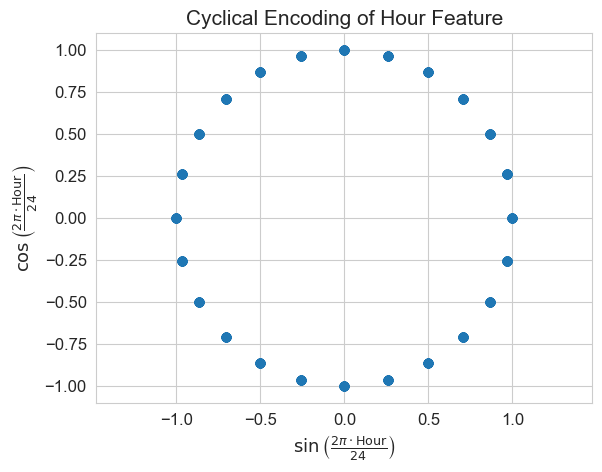

In [46]:
plt.figure()
plt.scatter(df['Hour sine'], df['Hour cosine'])
plt.xlabel(r'$\sin\left(\frac{2\pi \cdot \mathrm{Hour}}{24}\right)$',fontsize=13)
plt.ylabel(r'$\cos\left(\frac{2\pi \cdot \mathrm{Hour}}{24}\right)$',fontsize=13)
plt.title('Cyclical Encoding of Hour Feature',fontsize=15)
plt.tick_params(axis='both', labelsize=12)
plt.axis('equal')
plt.savefig("./figures/cyclical_encoding.png",bbox_inches="tight")
plt.show()

These components follow the unit circle, perfectly encapsulating the cyclical nature of `Hour`.

We can also extract the day of the week from `Timestamp` as a new feature (`Day of Week`), which represent each day of the week as integers (0=Monday, 6=Sunday). To preserve the cyclical nature of `Day of Week`, we can compute the sine and cosine components, similar to what we did above with `Hour`.

In [48]:
# extract day of the week
# 0 = Monday, 6 = Sunday
df['Day of Week'] = df['Timestamp'].dt.dayofweek

# compute sine and cosine components of day of week
df['Day of Week sine'] = np.sin(2.*np.pi*df['Day of Week']/7.)
df['Day of Week cosine'] = np.cos(2.*np.pi*df['Day of Week']/7.)

Let's review the results of `Day of Week`.

In [50]:
df['Day of Week'].value_counts()

Day of Week
6    159
2    156
4    155
3    142
0    140
5    126
1    122
Name: count, dtype: int64

Lastly, we'll define one final feature (`Weekend`) that indicates whether `Timestamp` occurs during the weekend (`=1`) or not (`=0`). 

In [52]:
# create weekend column
# 1 = weekend, 0 = weekday
df['Weekend'] = df['Day of Week'].isin([5,6]).astype(int)

Let's review the results of `Weekend`.

In [54]:
df['Weekend'].value_counts()

Weekend
0    715
1    285
Name: count, dtype: int64

With alternative temporal features created, let's drop `Timestamp`, `Hour`, and `Day of Week`.

In [56]:
# drop Timestamp, Hour, and Day of Week columns
df = df.drop(columns=['Timestamp', 'Hour', 'Day of Week'])

### Step 3.2. Feature Encoding

Next, we'll make sure that categorical features are properly encoded so they can be used by the model.

#### Step 3.2.1. One-Hot Encoding

We'll start by one-hot encoding the nominal features, which are categorical features that don't have a natural order. For this we'll use `panda`'s `pd.get_dummies()` function, which converts the categorical features into binary features. Using the `drop_first=True` argument drops the redundant binary column, which helps to reduce multicolinearity. I'll generate the dummy variables separately so we can easily convert them from boolean type (True or False) to integer values (1 or 0).

In [58]:
# define nominal features for one-hot encoding
nominal_features = ['Continent']

# create dummy variables for nominal features and convert to integer data type
df_dummies = pd.get_dummies(df[nominal_features],drop_first=True).astype(int)
encoded_nominal_features = df_dummies.columns.to_list()

# drop original nominal features from dataframe as they're now redundant
df = df.drop(columns=nominal_features)

# concatenate original dataframe with that containing the dummy variables
df = pd.concat([df, df_dummies], axis=1)

In [59]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Hour sine,Hour cosine,Day of Week sine,Day of Week cosine,Weekend,Continent_Antarctica,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America
0,68.95,35,61833.90,256.09,0,0,0.000000,1.000000,-0.781831,0.623490,1,0,0,0,0,0,0
1,80.23,31,68441.85,193.77,1,0,0.258819,0.965926,0.000000,1.000000,0,0,0,0,0,1,0
2,69.47,26,59785.94,236.50,0,0,-0.866025,0.500000,-0.781831,0.623490,1,0,0,1,0,0,0
3,74.15,29,54806.18,245.89,1,0,0.500000,0.866025,-0.781831,0.623490,1,0,0,1,0,0,0
4,68.37,35,73889.99,225.58,0,0,0.707107,0.707107,-0.433884,-0.900969,0,0,0,1,0,0,0


#### Step 3.2.2. Ordinal Encoding
There are no ordinal categorical features, so we don't need to worry about ordinal encoding.

#### Step 3.2.3. Binary Mapping
There are two binary features, `Male` and `Weekend` with values of 1 represent individuals being male or the timestamp occuring on the weekend, while values of 0 represent individuals that are female or the timestamp occurring during the week. In this case, the binary features are already in the proper format and don't need to be mapped. 

In [62]:
# define binary features
binary_features  = ['Male', 'Weekend']

With our features encoded, let's reorder the column names.

In [64]:
# define continuous features
continuous_features = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Hour sine', 'Hour cosine', 'Day of Week sine', 'Day of Week cosine']
# define target variable
target_variable = ['Clicked on Ad']

# reorder columns
df = df[continuous_features+encoded_nominal_features+binary_features+target_variable]
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Hour sine,Hour cosine,Day of Week sine,Day of Week cosine,Continent_Antarctica,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Male,Weekend,Clicked on Ad
0,68.95,35,61833.90,256.09,0.000000,1.000000,-0.781831,0.623490,0,0,0,0,0,0,0,1,0
1,80.23,31,68441.85,193.77,0.258819,0.965926,0.000000,1.000000,0,0,0,0,1,0,1,0,0
2,69.47,26,59785.94,236.50,-0.866025,0.500000,-0.781831,0.623490,0,0,1,0,0,0,0,1,0
3,74.15,29,54806.18,245.89,0.500000,0.866025,-0.781831,0.623490,0,0,1,0,0,0,1,1,0
4,68.37,35,73889.99,225.58,0.707107,0.707107,-0.433884,-0.900969,0,0,1,0,0,0,0,0,0


### Step 3.3. Feature Scaling
Let's map the continuous features using `scikit-learn`'s `StandardScaler` to ensure that their mean is zero and standard deviation is one.

In [66]:
# scale features
scaler = StandardScaler()
df[continuous_features] = scaler.fit_transform(df[continuous_features])

In [67]:
# preview results
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Hour sine,Hour cosine,Day of Week sine,Day of Week cosine,Continent_Antarctica,Continent_Asia,Continent_Europe,Continent_North America,Continent_Oceania,Continent_South America,Male,Weekend,Clicked on Ad
0,0.249267,-0.114905,0.509691,1.734030,-0.006225,1.415581,-1.102923,0.899513,0,0,0,0,0,0,0,1,0
1,0.961132,-0.570425,1.002530,0.313805,0.355348,1.366777,0.007557,1.429831,0,0,0,0,1,0,1,0,0
2,0.282083,-1.139826,0.356949,1.287589,-1.216071,0.699432,-1.102923,0.899513,0,0,1,0,0,0,0,1,0
3,0.577432,-0.798185,-0.014456,1.501580,0.692280,1.223690,-1.102923,0.899513,0,0,1,0,0,0,1,1,0
4,0.212664,-0.114905,1.408868,1.038731,0.981610,0.996071,-0.608713,-1.247701,0,0,1,0,0,0,0,0,0


## Step 4: Correlation Analysis
Before training the model, let's explore correlations between input features. Identifying input features that are correlated with each other and addressing multicollinearity is essential for logistic regression. We'll compute a correlation matrix of the input features using `panda`'s `.corr()` function and identify cases where the Pearson correlation coefficient indicates a strong correlation ($|r|>0.7$) and drop these multicollinear features as necessary to improve the model.

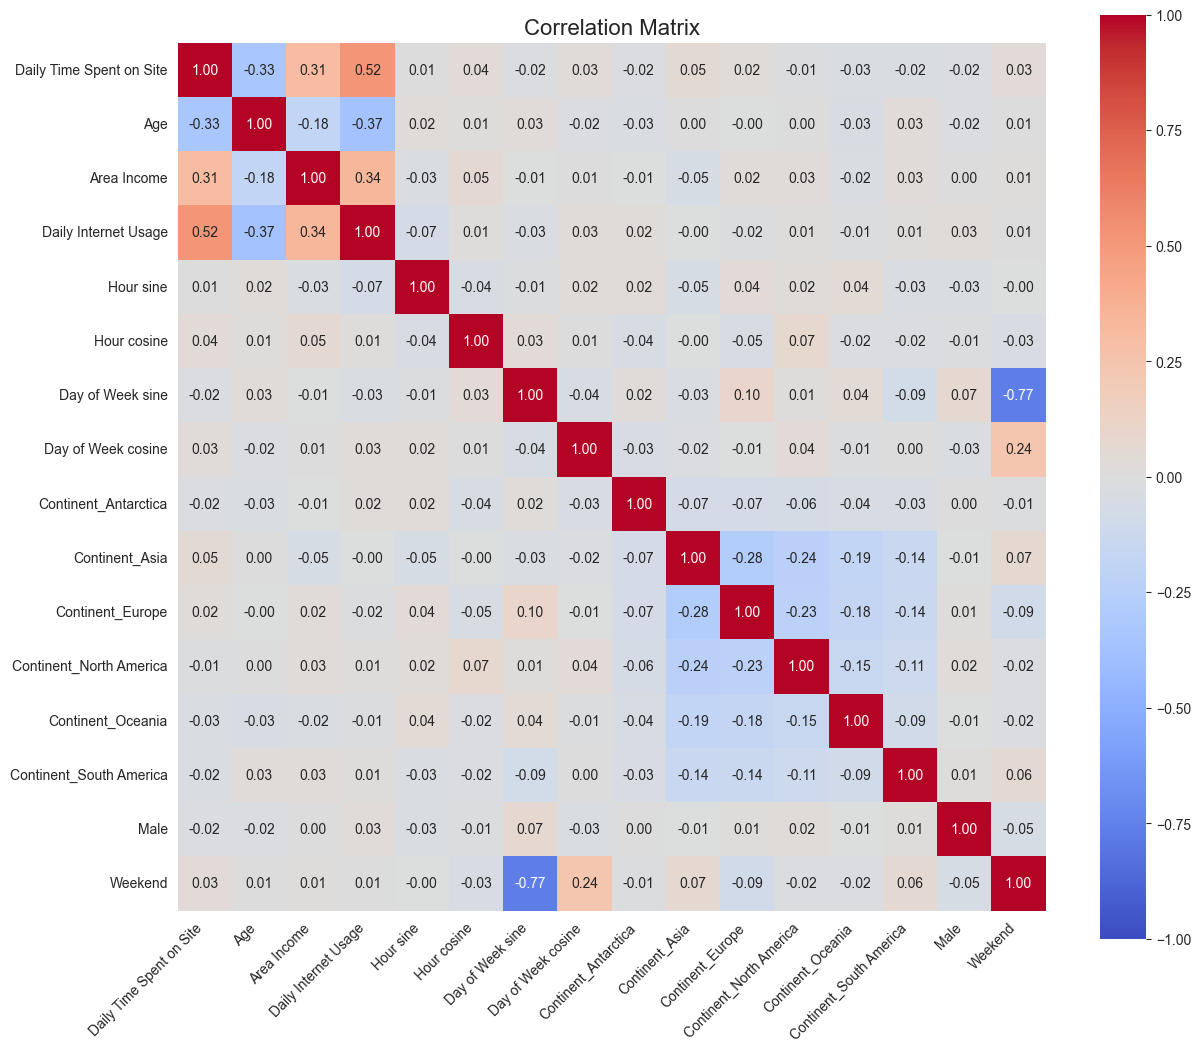

Pairs of correlated features: [('Day of Week sine', 'Weekend')]


In [69]:
corr_matrix =  df.drop(columns=target_variable).corr()

# correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",annot_kws={"size": 10},cmap="coolwarm",vmin=-1,vmax=1,square=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

corr_feature_pairs = []
# iterate through indices of upper-right triangle
# of correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i+1,len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        # correlated pairs if |r|>0.7
        if abs(r) > 0.7:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_feature_pairs.append((col1,col2))

print("Pairs of correlated features:", corr_feature_pairs)

This reveals that `Day of Week sine` and `Weekend` are highly correlated. Since `Weekend` is more intuitive, we will drop `Day of Week sine`.

In [71]:
# drop Day of Week sine column
df = df.drop(columns=['Day of Week sine'])

## Step 5. Logistic Regression Modelling
Our data have been cleaned and pre-processed so it's finally time to train a logistic regression model!

### Step 5.1. Train Test Split
I'll follow the standard process of separating the input features (`X`) from the target variable (`y`) and splitting the data into training (`_train`) and testing (`_test`) sets using `scikit-learn`'s `train_test_split()` function. Splitting the data into training and testing sets allows us to evaluate the model performance using an independent dataset that the model hasn't seen during its training phase. This is an essential step for determining how well the model generalizes to unseen data.

In [73]:
#separate input features from target variable
X = df.drop(columns=['Clicked on Ad'])
y = df['Clicked on Ad']

# split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Step 5.2. Train the Logistic Regression Model
All of our hard work has led to this: training the logistic regression model using `scikit-learn`'s `LogisticRegression()` function!

In [75]:
# train the logistic regression model
logm = LogisticRegression()
logm.fit(X_train,y_train)

LogisticRegression()

### Step 5.3. Make Predictions on the Test Set
With the logistic regression model trained, let's make predictions and take a look at the distribution of the predicted class labels.

In [77]:
# predict the target variable using the test set
y_pred = logm.predict(X_test)

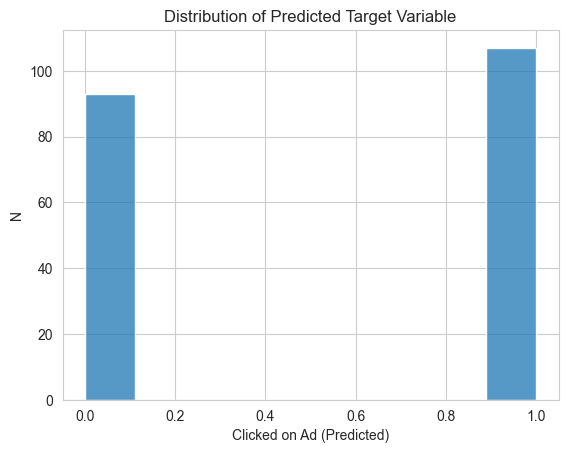

In [78]:
# plot distributions of predicted target variable
sns.histplot(y_pred)
plt.xlabel('Clicked on Ad (Predicted)')
plt.ylabel('N')
plt.title('Distribution of Predicted Target Variable')
plt.show()

It looks like a slightly higher number of individuals were predicted to have clicked on the ad (`=1`) than not (`=0`).

### Step 5.4. Test Model Performance

We will now test the model performance to get a better understanding of how well the logistic regression model performs on unseen data.

#### Step 5.4.1. Confusion Matrix

The confusion matrix is a diagnostic tool used to evaluate the performance of a classification model by summarizing how the predicted class labels compare to the actual class labels. For binary classification, the confusion matrix is a 2x2 matrix where the elements along the diagonal represent the true negative (TN) and true positive (TP) class labels (i.e., correct labels), while the off-diagonal elements represent the false negative (FN) and false positive (FP) class labels (i.e., incorrect labels). This simple structure demonstrates whether the model is able to properly separate positive and negative class labels, and whether there is any confusion between them.

It is worth noting that different sources use different conventions for the confusion matrix; `scikit-learn` uses the following convention: "...the count of true negatives is [0,0], false negatives is [1,0], true positives is [1,1] and false positives is [0,1]." Knowing this allows us to calculate two additional metrics that aren't included in the classification report (next step): the false positive rate (FPR) and false negative rate (FNR).

[[ 85   4]
 [  8 103]]


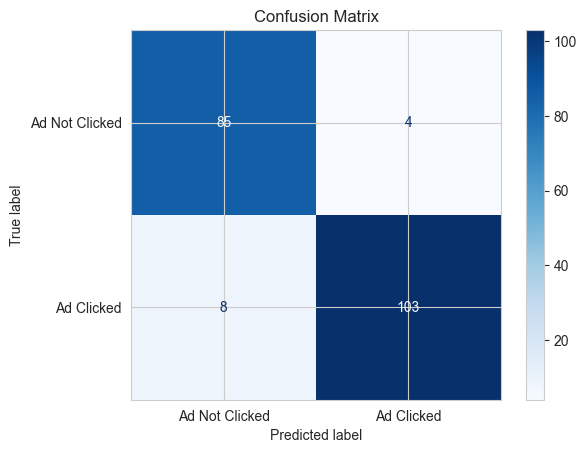

The FPR is 4.5% and the FNR is 7.2%.


In [81]:
# calculate confusion matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

# plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ad Not Clicked', 'Ad Clicked'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# define entries of confusion matrix
TN = cm[0,0]
FN = cm[1,0]
TP = cm[1,1]
FP = cm [0,1]

# calculate the FPR and FNR
FPR = FP/(FP+TN)
FNR = FN/(FN+TP)
print(f"The FPR is {FPR*100:.1f}% and the FNR is {FNR*100:.1f}%.")

The confusion matrix for this logistic model demonstrates that the vast majority of predictions are correct (94% being either TN or TP), with only a small fraction of predictions being errors (6% being either FN or FP). While we can calculate metrics like precision and recall from the confusion matrix, the classification report in the following section provides these metrics to us.

#### Step 5.4.2. Classification Report
The classification report is another common diagnostic tool used to evaluate the performance of a classification model, which summarizes four key metrics: precision, recall, f1-score, and support.

Precision quantifies how well you can trust a positive prediction, measured as the proportion of positive predictions that were correct:

$$
\begin{aligned}
\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}.
\end{aligned}
$$

The recall is complementary to precision, which quantifies the coverage of true positives measured as the proportion of true positives that were identified:

$$
\begin{aligned}
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}.
\end{aligned}
$$

The F1-score is the harmonic mean of precision and recall, which offers a more balanced metric and can be particularly useful when there is a class imbalance:

$$
\begin{aligned}
\text{F1-score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}.
\end{aligned}
$$

Lastly, support is the total number of occurrences in each class label and can help to provide context for the above key metrics, particularly in the case of a class imbalance.

In [84]:
# compute classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        89
           1       0.96      0.93      0.94       111

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



The classification report demonstrates a strong performance of the logistic regression model, with an average precision, recall, and f1-score of 94%. This means that the model has a strong coverage of positive cases (recall) and a high accuracy when predicting positive cases (precision). There is a minor class imbalance with 89/200 (44.5%) test samples belonging to the negative class and 111/200 (55.5%) test samples belonging to the positive class. As a result, the three metrics are slightly higher for the positive class compared to the negative class, although the differences are minor, indiacting that the model performs well across both classes.

#### Step 5.4.3. ROC-AUC Score
The ROC (Receiver Operating Characteristic) curve is a diagnostic tool that visualizes the trade-off between the True Positive Rate (TPR, also known as sensitivity or recall) and the False Positive Rate (FPR) at various classification thresholds. A perfect classifier would have a curve that hugs the top-left corner of the plot, while a model that performs no better than random chance would follow the diagonal line. The AUC (Area Under the Curve) quantifies the overall ability of the model to distinguish between classes. In the case of a perfect classifier, the AUC would be 1.0 since the ROC curve hugs the top-left cornere of the plot. In contrast, a classifier that is unable to discriminate between classes would have an AUC closer to 0.5 since the ROC curve would follow the diagonal.

In [87]:
# get predicted probabilities for positive class
y_proba = logm.predict_proba(X_test)[:,1] # extract second column

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# compute AUC score
auc_score = roc_auc_score(y_test, y_proba)

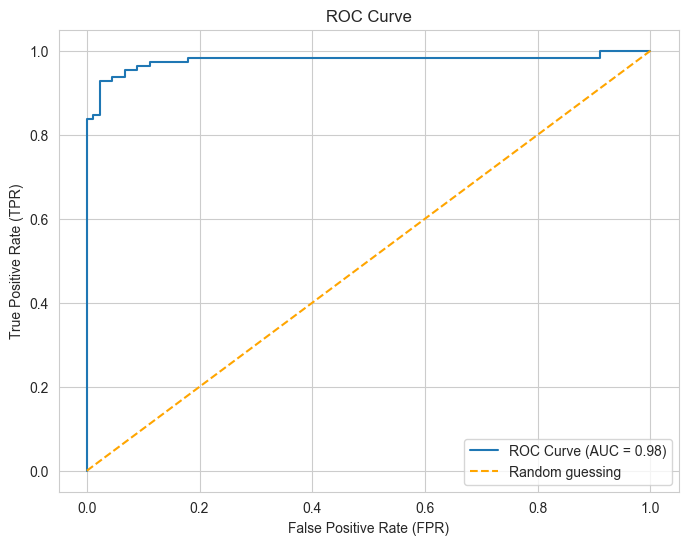

In [88]:
# plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.2f})") # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",label="Random guessing") # 1:1 line for random guessing
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve is very close to the top-left corner of the plot and has an AUC score of 0.98, both of which indicate that this model quickly obtains a high TPR while the FPR is low.

#### Step 5.4.4. Threshold Optimization with Youden's J Statistic

By default, `scikit-learn` uses a threshold of 0.5 for its logistic regression model. To test the validity of this threshold, we can compute Youden's J Statistic, which summarizes the model performance in terms of its true positive rate (TPR) and false positive rate (FPR),

\begin{align}
J = \mathrm{TPR - FPR}.
\end{align}

The value of $J$ ranges from 0 (no better than random change) to 1 (perfect classification). To identify the optimal threshold, we can compute the threshold that corresponds to a maximum value in $J$, which maximizes the TPR and minimizes the FPR.

Optimal threshold: 0.61


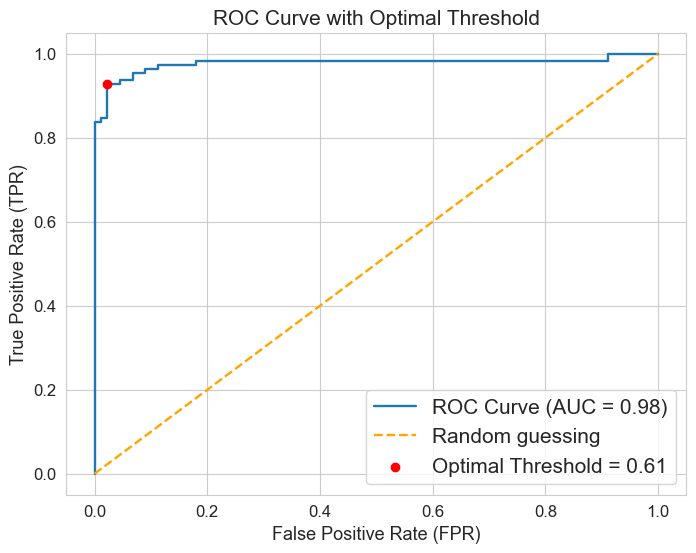

In [90]:
# compute Youden's J statistic
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")

# plot ROC curve and optimal threshold
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,linewidth=1.7,label=f"ROC Curve (AUC = {auc_score:.2f})",zorder=1) # ROC curve with AUC score
plt.plot([0,1],[0,1],color="orange",linestyle="dashed",linewidth=1.7,label="Random guessing",zorder=2) # 1:1 line for random guessing
plt.scatter(fpr[optimal_idx],tpr[optimal_idx],color='red',label=f'Optimal Threshold = {optimal_threshold:.2f}',zorder=3) # optimal threshold
plt.xlabel("False Positive Rate (FPR)",fontsize=13)
plt.ylabel("True Positive Rate (TPR)",fontsize=13)
plt.title("ROC Curve with Optimal Threshold",fontsize=15)
plt.legend(prop={"size":15})
plt.tick_params(axis='both', labelsize=12)
plt.grid(zorder=0)
plt.savefig("./figures/ROC.png",bbox_inches="tight")
plt.show()

This yield an optimal threshold of 0.61. Let's re-evaluate the predictions based on the probabilities that were output by the model.

In [92]:
# re-evaluate predictions using optimal threshold
y_pred_optimal = (y_proba>0.61).astype(int)

We can now re-evaluate some of the standard plots and metrics that we used previously to investigate the results of the optimal threshold.

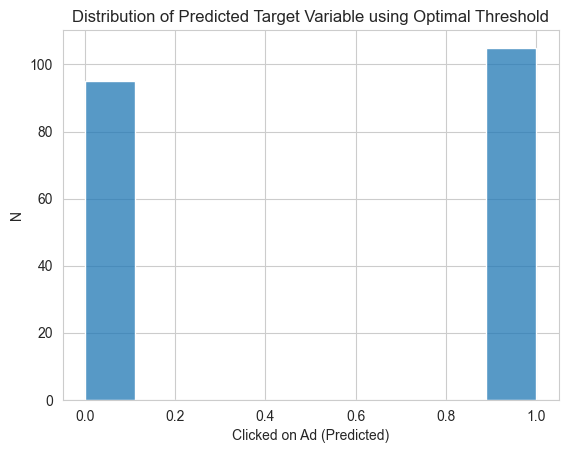

In [94]:
# plot distributions of predicted target variable using optimal threshold
sns.histplot(y_pred_optimal)
plt.xlabel('Clicked on Ad (Predicted)')
plt.ylabel('N')
plt.title('Distribution of Predicted Target Variable using Optimal Threshold')
plt.show()

[[ 87   2]
 [  8 103]]


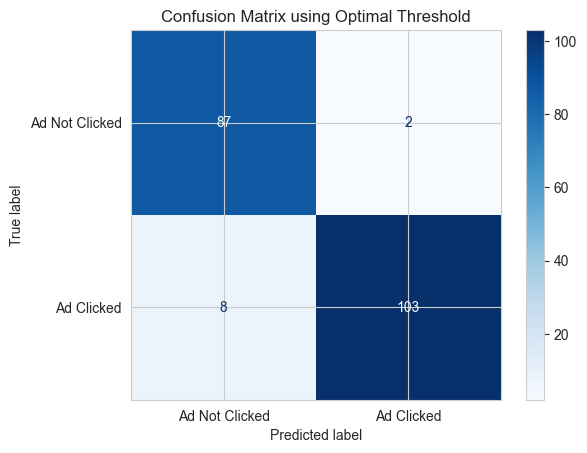

The FPR is 2.2% (from 4.5%) and the FNR is 7.2% (from 7.2%).


In [95]:
# calculate confusion matrix
cm_optimal = confusion_matrix(y_test,y_pred_optimal)
print(cm_optimal)

# plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['Ad Not Clicked', 'Ad Clicked'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix using Optimal Threshold')
plt.show()

# define entries of confusion matrix
TN_optimal = cm_optimal[0,0]
FN_optimal = cm_optimal[1,0]
TP_optimal = cm_optimal[1,1]
FP_optimal = cm_optimal [0,1]

# calculate the FPR and FNR
FPR_optimal = FP_optimal/(FP_optimal+TN_optimal)
FNR_optimal = FN_optimal/(FN_optimal+TP_optimal)
print(f"The FPR is {FPR_optimal*100:.1f}% (from {FPR*100:.1f}%) and the FNR is {FNR_optimal*100:.1f}% (from {FNR*100:.1f}%).")

In [96]:
# classification report
print(classification_report(y_test,y_pred_optimal))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        89
           1       0.98      0.93      0.95       111

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



Using the optimal threshold identified using Youden's J statistic reduced the FPR by 2.3% and increased the average precision, recall, and f1-score by 1%.

## Step 6. Summary
This demonstrates the end-to-end process of building a logistic regression model to predict whether an individual will click on an online ad based on behavioural and demographic input features. The dataset have 1,000 data samples, 9 input features, and one target variable (`Clicked on Ad`).

Among the categorical features, four high-cardinality. `Ad Topic Line` and `Timestamp` were unique for each individual, while `City` was nearly unique. Since these features did not add value to the model, `Ad Topic Line` and `City` were dropped. `Country` was transformed into a lower cardinality feature `Continent`, reducing the number of unique labels from 74 to 7.

To extract meaningful temporal features, `timestamp` was decomposed into several components. First, the sine and cosine components of the hour were computed to produce `Hour sine` and `Hour cosine`, which preserved the cyclical nature of time. Similarly, the sine and cosine components of the day of the week (`Day of Week sine` and `Day of Week cosine`) were also computed. Lastly, a binary feature (`Weekend`) was defined to identify whether `timestamp` occurred during the weekend. 

After feature encoding and scaling, a correlation analysis was used to identify multicollinearity. This revealed that `Day of Week sine` and `Weekend` were highly correlated ($|r|>0.7$). Since `Weekend` is more intuitive, `Day of Week sine` was dropped.

The logistic regression model performed strongly, achieving an average precision, recall, and f1-score of 95%. On the test set of 200 samples, the FPR was 4.5% and the FNR was 7.2%. The ROC curve closely hugged the top left corner and the AUC score was 0.98, indicating that the logistic regression model quickly obtained a high TPR while maintaining a low FPR.

To optimize the model, I used Youden's J statistic to compute the optimal classification threshold of 0.61 (as opposed to the standard value of 0.5). This reduced the FPR by 2.3% and increased the average precision, recall, and f1-score by 1%. 